# FinSight — 02 · Feature Engineering

**Objectif :** Calculer tous les indicateurs techniques, visualiser leur comportement sur les actifs, et vérifier la qualité de la matrice de features avant la modélisation.

**Plan :**
1. Configuration et chargement des données brutes
2. Indicateurs techniques — calcul et visualisation
   - RSI
   - MACD
   - Bandes de Bollinger
   - EMA et croisement
   - Volume relatif
   - Rendements passés
   - Volatilité historique
3. Features macroéconomiques (FRED)
4. Construction de la matrice de features complète
5. Variables cibles — tendance et volatilité
6. Vérification qualité (NaN, distributions, corrélations)
7. Sauvegarde dans data/processed/

## 1. Configuration et chargement

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

from src.config import (
    ALL_TICKERS, TICKER_LABELS,
    TRAIN_START_DATE, TEST_END_DATE,
    RSI_WINDOW, MACD_FAST, MACD_SLOW, MACD_SIGNAL,
    BOLLINGER_WINDOW, EMA_SHORT, EMA_LONG,
    TREND_UP_THRESHOLD, TREND_DOWN_THRESHOLD,
    PREDICTION_HORIZON_DAYS, DATA_PROCESSED_DIR,
)
from src.data.collector import load_raw_prices, load_fred_data
from src.data.features import (
    add_rsi, add_macd, add_bollinger_bands, add_ema,
    add_volume_features, add_returns, add_historical_volatility,
    add_trend_target, add_volatility_target,
    build_feature_matrix, get_feature_names,
)

load_dotenv('../.env')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

# On travaille sur AAPL pour les visualisations — actif très liquide et bien connu
TICKER = 'AAPL'
df_raw = load_raw_prices(TICKER)
macro  = load_fred_data()

print(f'Données chargées : {TICKER_LABELS[TICKER]}')
print(f'Shape : {df_raw.shape}')
df_raw.head()

Données chargées : Apple
Shape : (2515, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400
2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000
2015-01-06,23.575230,23.772169,23.152583,23.513271,263188400
2015-01-07,23.721280,23.942561,23.610640,23.842985,160423600
2015-01-08,24.170475,24.816614,24.053195,24.759081,237458000


## 2. Indicateurs techniques

### 2.1 RSI — Relative Strength Index

Le RSI mesure la vitesse et l'amplitude des mouvements de prix sur une fenêtre de 14 jours.
- RSI > 70 → actif **suracheté** (signal de retournement baissier possible)
- RSI < 30 → actif **survendu** (signal de retournement haussier possible)
- Entre 30 et 70 → zone neutre

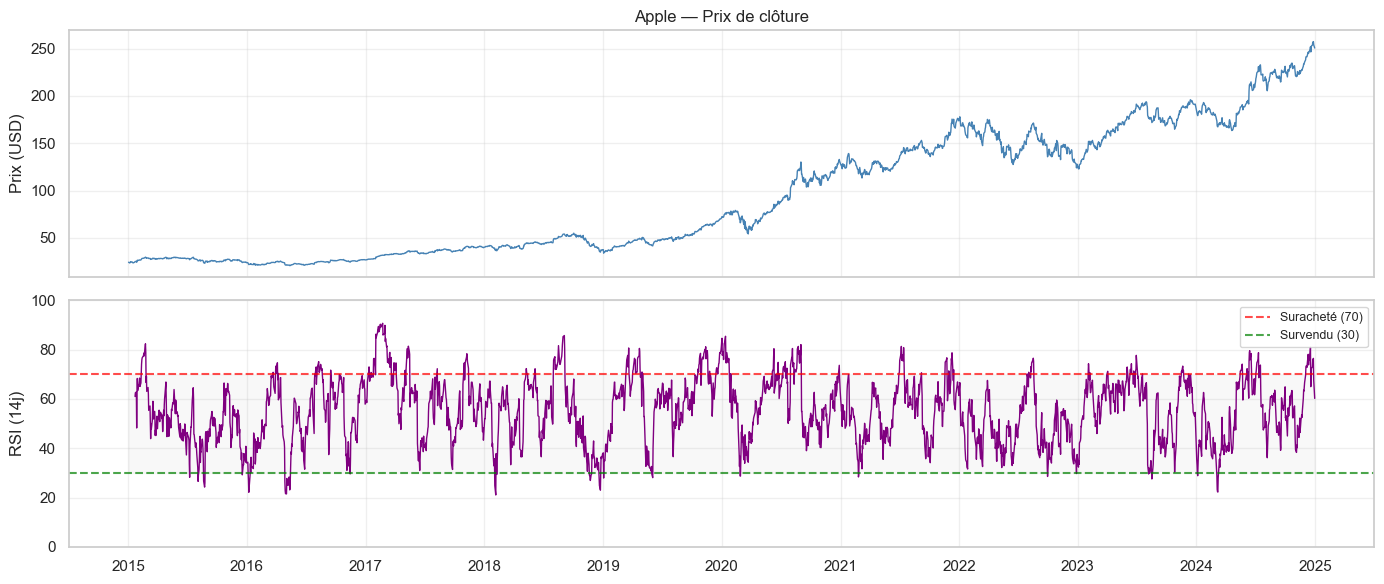

RSI — Statistiques :
count    2502.00
mean       55.41
std        13.04
min        21.03
25%        45.44
50%        55.98
75%        64.92
max        90.70
Name: rsi, dtype: float64


In [2]:
df_rsi = add_rsi(df_raw, window=RSI_WINDOW)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df_rsi.index, df_rsi['Close'], color='steelblue', linewidth=1)
ax1.set_ylabel('Prix (USD)')
ax1.set_title(f'{TICKER_LABELS[TICKER]} — Prix de clôture')

ax2.plot(df_rsi.index, df_rsi['rsi'], color='purple', linewidth=1)
ax2.axhline(70, color='red',   linestyle='--', alpha=0.7, label='Suracheté (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Survendu (30)')
ax2.fill_between(df_rsi.index, 30, 70, alpha=0.05, color='gray')
ax2.set_ylabel(f'RSI ({RSI_WINDOW}j)')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f"RSI — Statistiques :")
print(df_rsi['rsi'].describe().round(2))

### 2.2 MACD — Moving Average Convergence Divergence

Le MACD est la différence entre deux moyennes mobiles exponentielles (12j et 26j).
- Quand le MACD **croise à la hausse** sa ligne signal → signal d'achat
- Quand il **croise à la baisse** → signal de vente
- L'histogramme (macd_diff) visualise l'écart entre MACD et signal

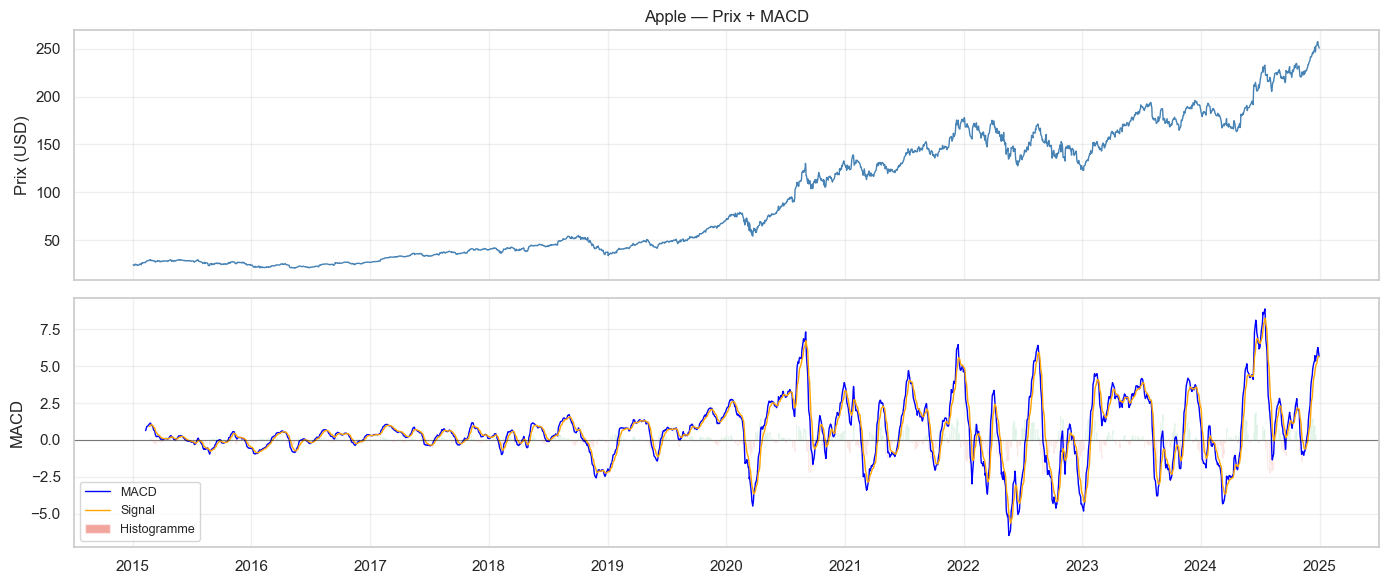

In [3]:
df_macd = add_macd(df_raw, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df_macd.index, df_macd['Close'], color='steelblue', linewidth=1)
ax1.set_ylabel('Prix (USD)')
ax1.set_title(f'{TICKER_LABELS[TICKER]} — Prix + MACD')

ax2.plot(df_macd.index, df_macd['macd'],        color='blue',   linewidth=1,   label='MACD')
ax2.plot(df_macd.index, df_macd['macd_signal'], color='orange', linewidth=1,   label='Signal')
ax2.bar(df_macd.index,  df_macd['macd_diff'],
        color=df_macd['macd_diff'].apply(lambda x: '#27ae60' if x >= 0 else '#e74c3c'),
        alpha=0.5, width=1, label='Histogramme')
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('MACD')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 2.3 Bandes de Bollinger

Les bandes de Bollinger encadrent le prix avec ±2 écarts-types sur 20 jours.
- **bb_width** : largeur des bandes (proxy de la volatilité implicite)
- **bb_pct_b** : position du prix dans les bandes (0 = bas de bande, 1 = haut de bande)

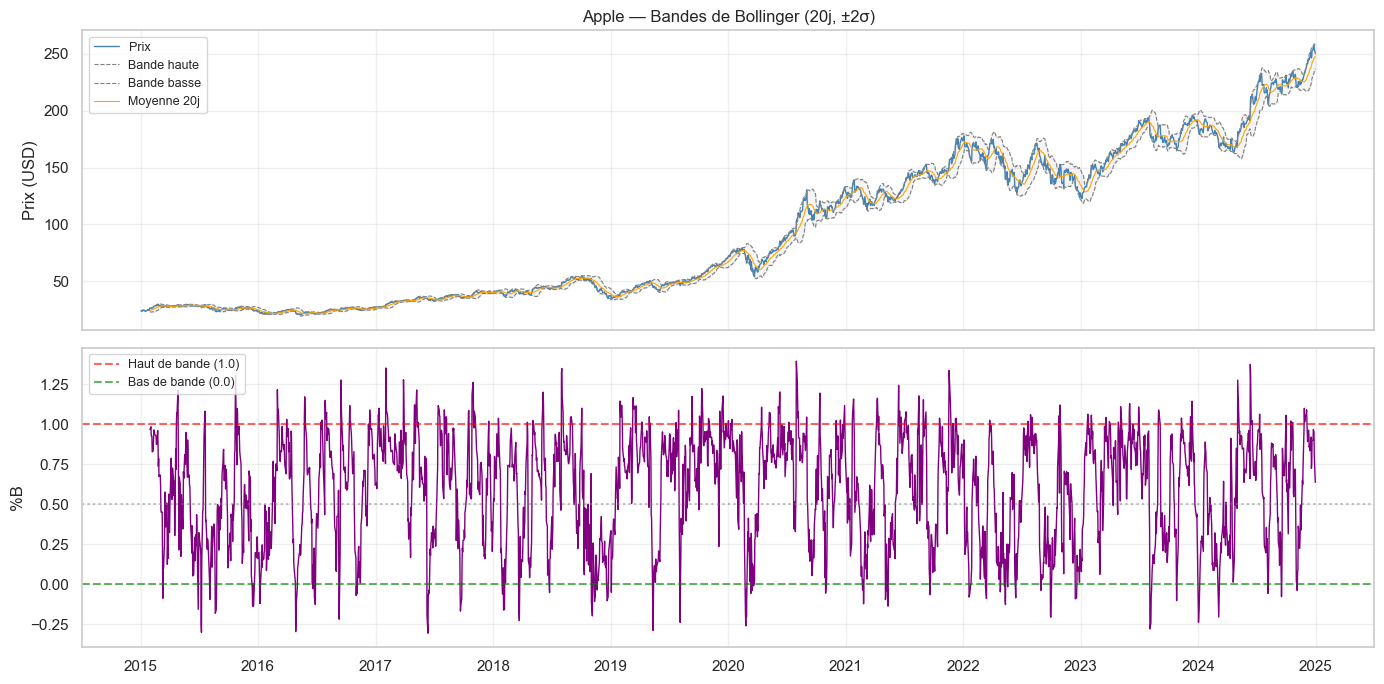

In [5]:
import ta

df_bb = add_bollinger_bands(df_raw, window=BOLLINGER_WINDOW)
bb    = ta.volatility.BollingerBands(close=df_raw['Close'], window=BOLLINGER_WINDOW, window_dev=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Prix + bandes
ax1.plot(df_raw.index, df_raw['Close'],     color='steelblue', linewidth=1,   label='Prix')
ax1.plot(df_raw.index, bb.bollinger_hband(), color='gray',      linewidth=0.8, linestyle='--', label='Bande haute')
ax1.plot(df_raw.index, bb.bollinger_lband(), color='gray',      linewidth=0.8, linestyle='--', label='Bande basse')
ax1.plot(df_raw.index, bb.bollinger_mavg(),  color='orange',    linewidth=0.8, label='Moyenne 20j')
ax1.fill_between(df_raw.index, bb.bollinger_lband(), bb.bollinger_hband(), alpha=0.08, color='gray')
ax1.set_ylabel('Prix (USD)')
ax1.set_title(f'{TICKER_LABELS[TICKER]} — Bandes de Bollinger ({BOLLINGER_WINDOW}j, ±2σ)')
ax1.legend(fontsize=9)

# %B — position dans les bandes
ax2.plot(df_bb.index, df_bb['bb_pct_b'], color='purple', linewidth=1)
ax2.axhline(1.0, color='red',   linestyle='--', alpha=0.6, label='Haut de bande (1.0)')
ax2.axhline(0.0, color='green', linestyle='--', alpha=0.6, label='Bas de bande (0.0)')
ax2.axhline(0.5, color='gray',  linestyle=':',  alpha=0.5)
ax2.set_ylabel('%B')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 2.4 EMA et croisement

Les moyennes mobiles exponentielles (EMA) donnent plus de poids aux prix récents.
Le **croisement EMA** est un signal classique :
- EMA 20j > EMA 50j → tendance haussière (ema_cross = +1)
- EMA 20j < EMA 50j → tendance baissière (ema_cross = -1)

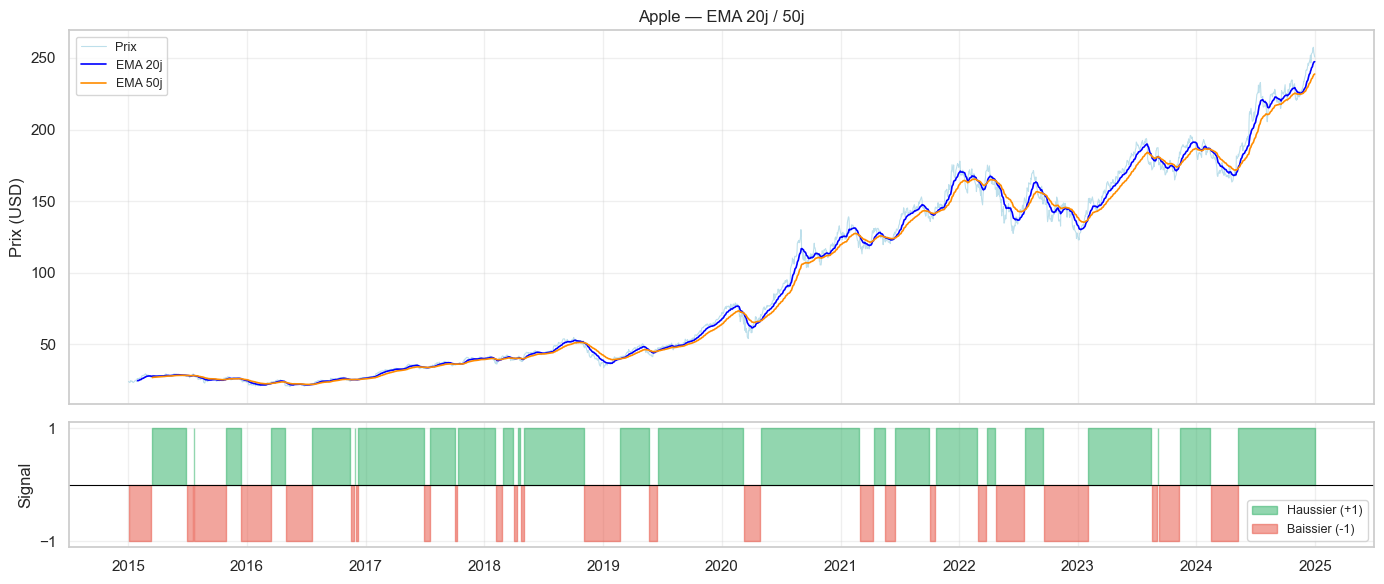

In [6]:
df_ema = add_ema(df_raw, short=EMA_SHORT, long=EMA_LONG)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df_ema.index, df_ema['Close'],     color='lightblue',  linewidth=0.8, alpha=0.8, label='Prix')
ax1.plot(df_ema.index, df_ema['ema_short'], color='blue',       linewidth=1.2, label=f'EMA {EMA_SHORT}j')
ax1.plot(df_ema.index, df_ema['ema_long'],  color='darkorange', linewidth=1.2, label=f'EMA {EMA_LONG}j')
ax1.set_ylabel('Prix (USD)')
ax1.set_title(f'{TICKER_LABELS[TICKER]} — EMA {EMA_SHORT}j / {EMA_LONG}j')
ax1.legend(fontsize=9)

# Signal de croisement (+1 / -1)
ax2.fill_between(df_ema.index, df_ema['ema_cross'],
                 where=df_ema['ema_cross'] > 0, color='#27ae60', alpha=0.5, label='Haussier (+1)')
ax2.fill_between(df_ema.index, df_ema['ema_cross'],
                 where=df_ema['ema_cross'] < 0, color='#e74c3c', alpha=0.5, label='Baissier (-1)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Signal')
ax2.set_yticks([-1, 1])
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 2.5 Volume relatif, rendements et volatilité historique

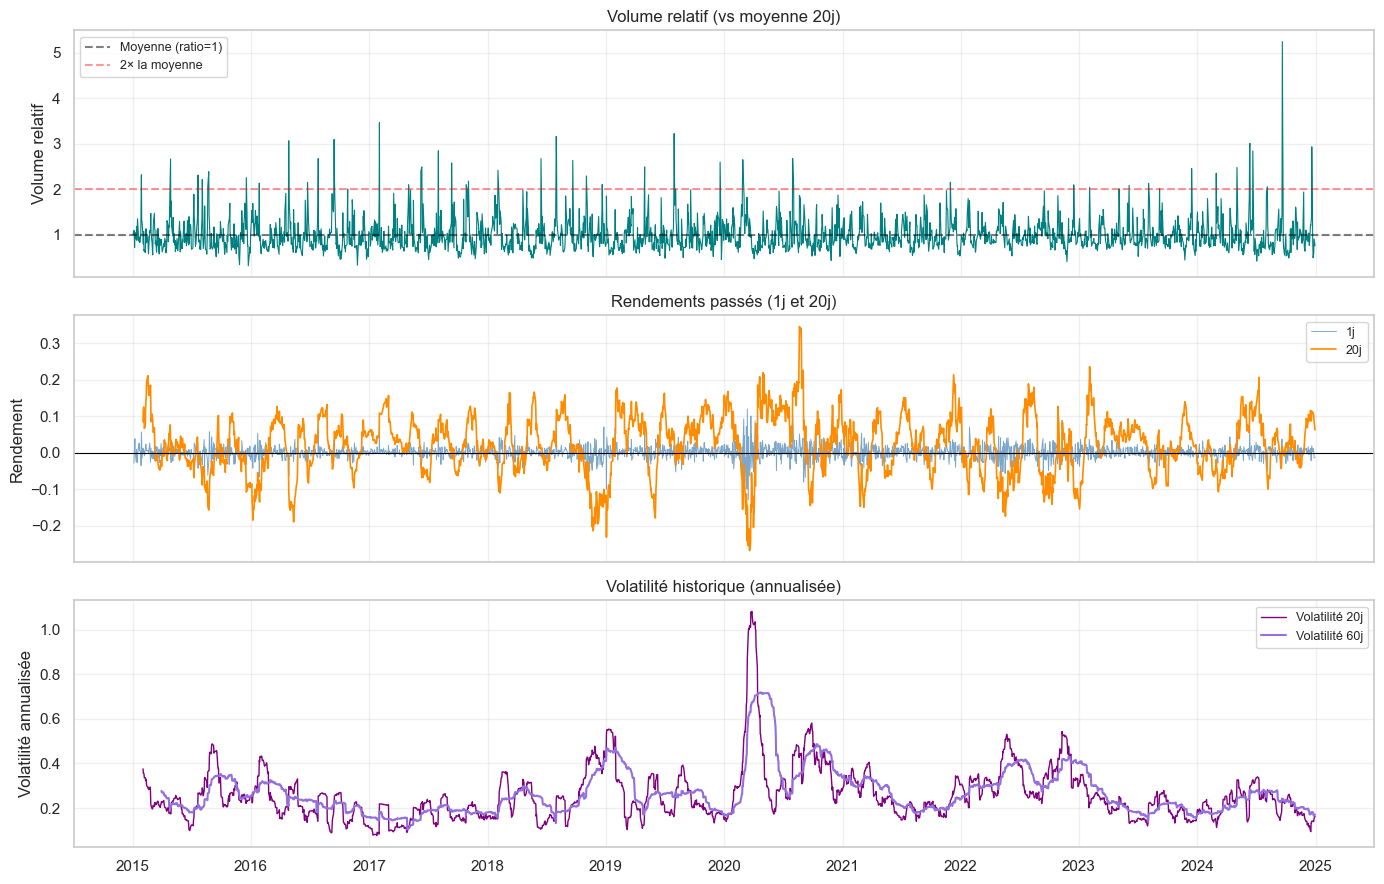

In [7]:
df_vol_feat = add_volume_features(df_raw)
df_ret      = add_returns(df_raw)
df_hvol     = add_historical_volatility(df_raw)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Volume relatif
axes[0].plot(df_vol_feat.index, df_vol_feat['volume_ratio'], color='teal', linewidth=0.8)
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Moyenne (ratio=1)')
axes[0].axhline(2.0, color='red',   linestyle='--', alpha=0.4, label='2× la moyenne')
axes[0].set_ylabel('Volume relatif')
axes[0].set_title('Volume relatif (vs moyenne 20j)')
axes[0].legend(fontsize=9)

# Rendements passés
axes[1].plot(df_ret.index, df_ret['return_1d'],  color='steelblue', linewidth=0.7, alpha=0.7, label='1j')
axes[1].plot(df_ret.index, df_ret['return_20d'], color='darkorange', linewidth=1.2, label='20j')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Rendement')
axes[1].set_title('Rendements passés (1j et 20j)')
axes[1].legend(fontsize=9)

# Volatilité historique
axes[2].plot(df_hvol.index, df_hvol['volatility_20d'], color='purple',      linewidth=1, label='Volatilité 20j')
axes[2].plot(df_hvol.index, df_hvol['volatility_60d'], color='mediumpurple', linewidth=1.5, label='Volatilité 60j')
axes[2].set_ylabel('Volatilité annualisée')
axes[2].set_title('Volatilité historique (annualisée)')
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 3. Features macroéconomiques

In [8]:
print('Données FRED :')
print(macro.shape)
macro.tail()

# Alignement sur l'index des prix (les séries FRED sont mensuelles → forward-fill)
macro_aligned = macro.reindex(df_raw.index, method='ffill')
print(f'\nAprès alignement sur les jours de marché : {macro_aligned.shape}')
print(f'Valeurs manquantes : {macro_aligned.isnull().sum().to_dict()}')

Données FRED :
(2642, 3)

Après alignement sur les jours de marché : (2515, 3)
Valeurs manquantes : {'fed_rate': 0, 'cpi': 0, 'us_10y': 0}


## 4. Construction de la matrice complète

In [9]:
# build_feature_matrix applique toutes les fonctions ci-dessus en une seule fois
df_features = build_feature_matrix(df_raw, macro_df=macro, add_targets=True)

print('Matrice de features :')
print(f'  Shape       : {df_features.shape}')
print(f'  Colonnes    : {list(df_features.columns)}')
print(f'  Période     : {df_features.index.min().date()} → {df_features.index.max().date()}')
print(f'  Manquants   : {df_features.isnull().sum().sum()} (dans targets = normal)')
df_features.head()

Matrice de features :
  Shape       : (2455, 25)
  Colonnes    : ['Open', 'High', 'Low', 'Close', 'Volume', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_width', 'bb_pct_b', 'ema_short', 'ema_long', 'ema_cross', 'volume_ratio', 'return_1d', 'return_5d', 'return_20d', 'volatility_20d', 'volatility_60d', 'fed_rate', 'cpi', 'us_10y', 'target_trend', 'target_volatility']
  Période     : 2015-03-31 → 2024-12-30
  Manquants   : 60 (dans targets = normal)


,Open,High,Low,Close,Volume,rsi,macd,macd_signal,macd_diff,bb_width,...,return_1d,return_5d,return_20d,volatility_20d,volatility_60d,fed_rate,cpi,us_10y,target_trend,target_volatility
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-31,28.011377,28.100239,27.627052,27.642603,168362400,48.349758,0.038775,0.142360,-0.103586,5.647809,...,-0.015352,-0.017839,-0.038111,0.228819,0.277183,0.11,235.976,1.94,1.0,1.0
2015-04-01,27.729251,27.795897,27.347146,27.602623,162485600,47.932381,0.016288,0.117146,-0.100858,5.316878,...,-0.001446,0.007051,-0.033374,0.228225,0.269786,0.12,236.222,1.87,2.0,1.0
2015-04-02,27.775896,27.893637,27.589287,27.840321,128880400,50.659508,0.017446,0.097206,-0.079760,5.270865,...,0.008611,0.008693,-0.008623,0.223771,0.269999,0.12,236.222,1.92,2.0,1.0
2015-04-06,27.651490,28.326838,27.620388,28.291292,148776000,55.429267,0.054129,0.088591,-0.034461,5.382439,...,0.016199,0.033265,0.005924,0.231289,0.270411,0.12,236.222,1.92,1.0,1.0
2015-04-07,28.355723,28.462355,27.986948,27.993612,140049200,51.865137,0.058506,0.082574,-0.024067,5.256282,...,-0.010522,-0.002849,-0.008888,0.233899,0.261799,0.12,236.222,1.89,2.0,1.0


## 5. Variables cibles

### Cible tendance
Rendement à J+30 :
- **2 (hausse)** si rendement > +3%
- **0 (baisse)** si rendement < -3%
- **1 (stable)** sinon

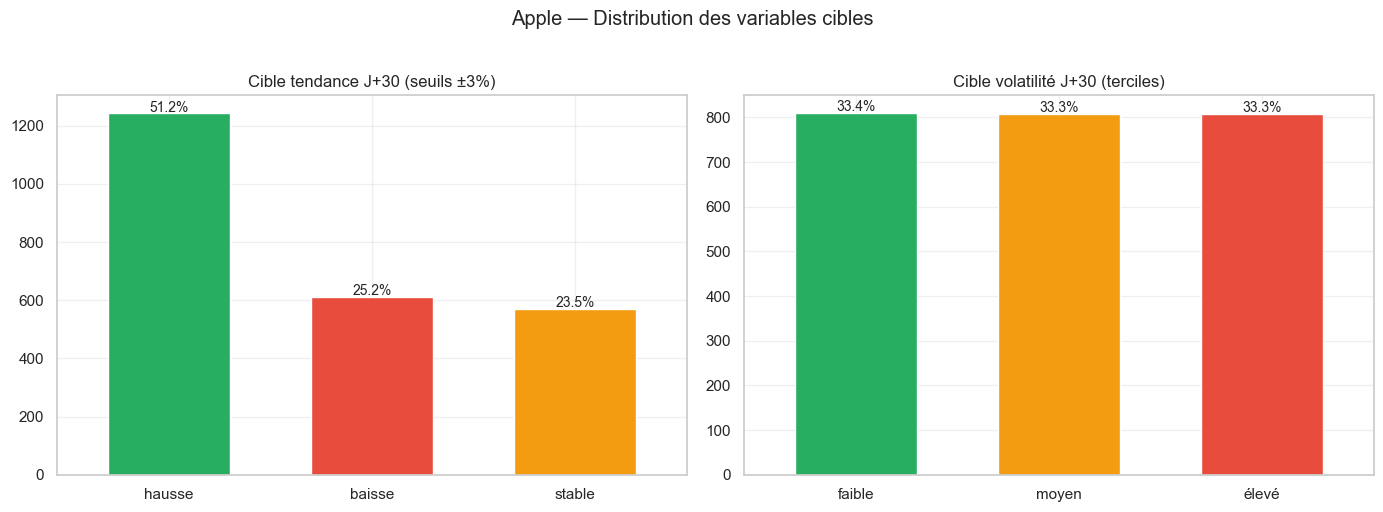

Tendance  : {'hausse': 1242, 'baisse': 612, 'stable': 571}
Volatilité: {'faible': 809, 'moyen': 808, 'élevé': 808}


In [10]:
df_clean = df_features.dropna(subset=['target_trend', 'target_volatility'])

from src.config import TREND_LABELS, VOLATILITY_LABELS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution cible tendance
COLORS_TREND = {'baisse': '#e74c3c', 'stable': '#f39c12', 'hausse': '#27ae60'}
counts_trend = df_clean['target_trend'].map(TREND_LABELS).value_counts()
colors = [COLORS_TREND[k] for k in counts_trend.index]
counts_trend.plot(kind='bar', ax=ax1, color=colors, edgecolor='white', width=0.6)
for p in ax1.patches:
    ax1.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
             f'{p.get_height()/len(df_clean):.1%}', ha='center', fontsize=10)
ax1.set_title(f'Cible tendance J+{PREDICTION_HORIZON_DAYS} (seuils ±{int(TREND_UP_THRESHOLD*100)}%)')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=0)

# Distribution cible volatilité
COLORS_VOL = {'faible': '#27ae60', 'moyen': '#f39c12', 'élevé': '#e74c3c'}
counts_vol = df_clean['target_volatility'].map(VOLATILITY_LABELS).value_counts()
colors_v = [COLORS_VOL.get(k, 'gray') for k in counts_vol.index]
counts_vol.plot(kind='bar', ax=ax2, color=colors_v, edgecolor='white', width=0.6)
for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
             f'{p.get_height()/len(df_clean):.1%}', ha='center', fontsize=10)
ax2.set_title(f'Cible volatilité J+{PREDICTION_HORIZON_DAYS} (terciles)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)

plt.suptitle(f'{TICKER_LABELS[TICKER]} — Distribution des variables cibles', y=1.02)
plt.tight_layout()
plt.show()

print('Tendance  :', counts_trend.to_dict())
print('Volatilité:', counts_vol.to_dict())

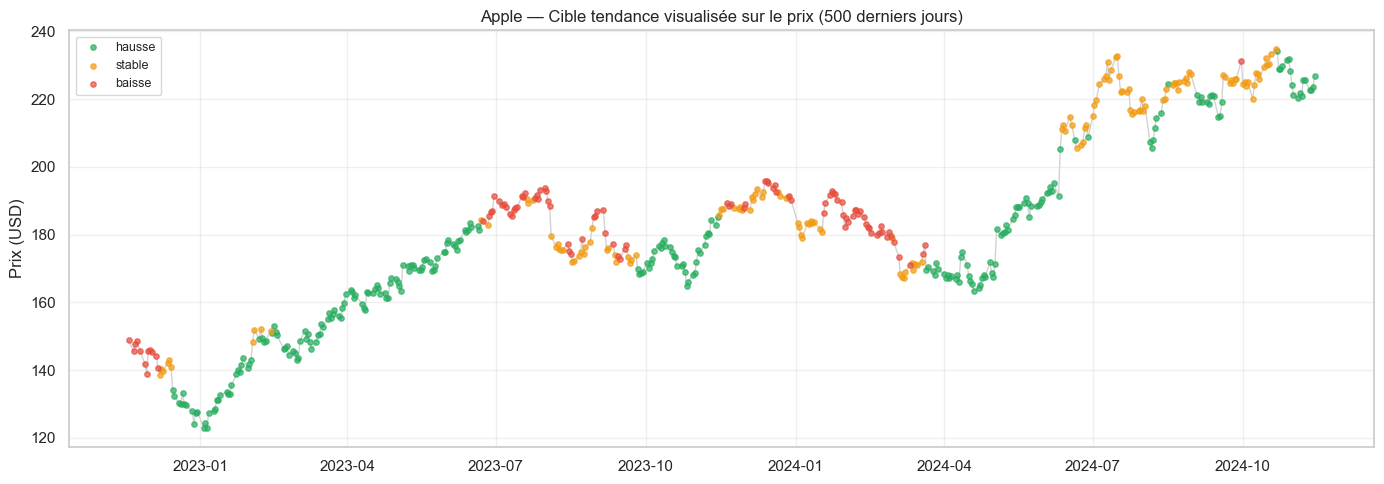

In [11]:
# Visualisation de la cible tendance sur le prix
# Permet de vérifier visuellement que les labels sont cohérents
fig, ax = plt.subplots(figsize=(14, 5))

sample = df_clean.iloc[-500:]  # 2 dernières années
ax.plot(sample.index, sample['Close'], color='lightgray', linewidth=1, zorder=1)

for label_int, color, label_str in [(2, '#27ae60', 'hausse'), (1, '#f39c12', 'stable'), (0, '#e74c3c', 'baisse')]:
    mask = sample['target_trend'] == label_int
    ax.scatter(sample.index[mask], sample['Close'][mask],
               color=color, s=15, alpha=0.7, label=label_str, zorder=2)

ax.set_title(f'{TICKER_LABELS[TICKER]} — Cible tendance visualisée sur le prix (500 derniers jours)')
ax.set_ylabel('Prix (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

## 6. Vérification qualité

In [12]:
feature_cols = get_feature_names(include_macro=True)
available    = [c for c in feature_cols if c in df_clean.columns]

print(f'Features disponibles ({len(available)}) :')
for f in available:
    n_nan = df_clean[f].isnull().sum()
    print(f'  {f:20s} | manquants: {n_nan:4d} | min: {df_clean[f].min():.4f} | max: {df_clean[f].max():.4f}')

Features disponibles (18) :
  rsi                  | manquants:    0 | min: 21.0301 | max: 90.6953
  macd                 | manquants:    0 | min: -6.4769 | max: 8.8785
  macd_signal          | manquants:    0 | min: -5.6428 | max: 8.2487
  macd_diff            | manquants:    0 | min: -2.4646 | max: 2.3243
  bb_width             | manquants:    0 | min: 3.0016 | max: 35.3387
  bb_pct_b             | manquants:    0 | min: -0.3067 | max: 1.3928
  ema_short            | manquants:    0 | min: 21.7685 | max: 229.2323
  ema_long             | manquants:    0 | min: 22.1039 | max: 225.3812
  ema_cross            | manquants:    0 | min: -1.0000 | max: 1.0000
  volume_ratio         | manquants:    0 | min: 0.3192 | max: 5.2456
  return_1d            | manquants:    0 | min: -0.1286 | max: 0.1198
  return_5d            | manquants:    0 | min: -0.1753 | max: 0.1841
  return_20d           | manquants:    0 | min: -0.2677 | max: 0.3453
  volatility_20d       | manquants:    0 | min: 0.0763 | m

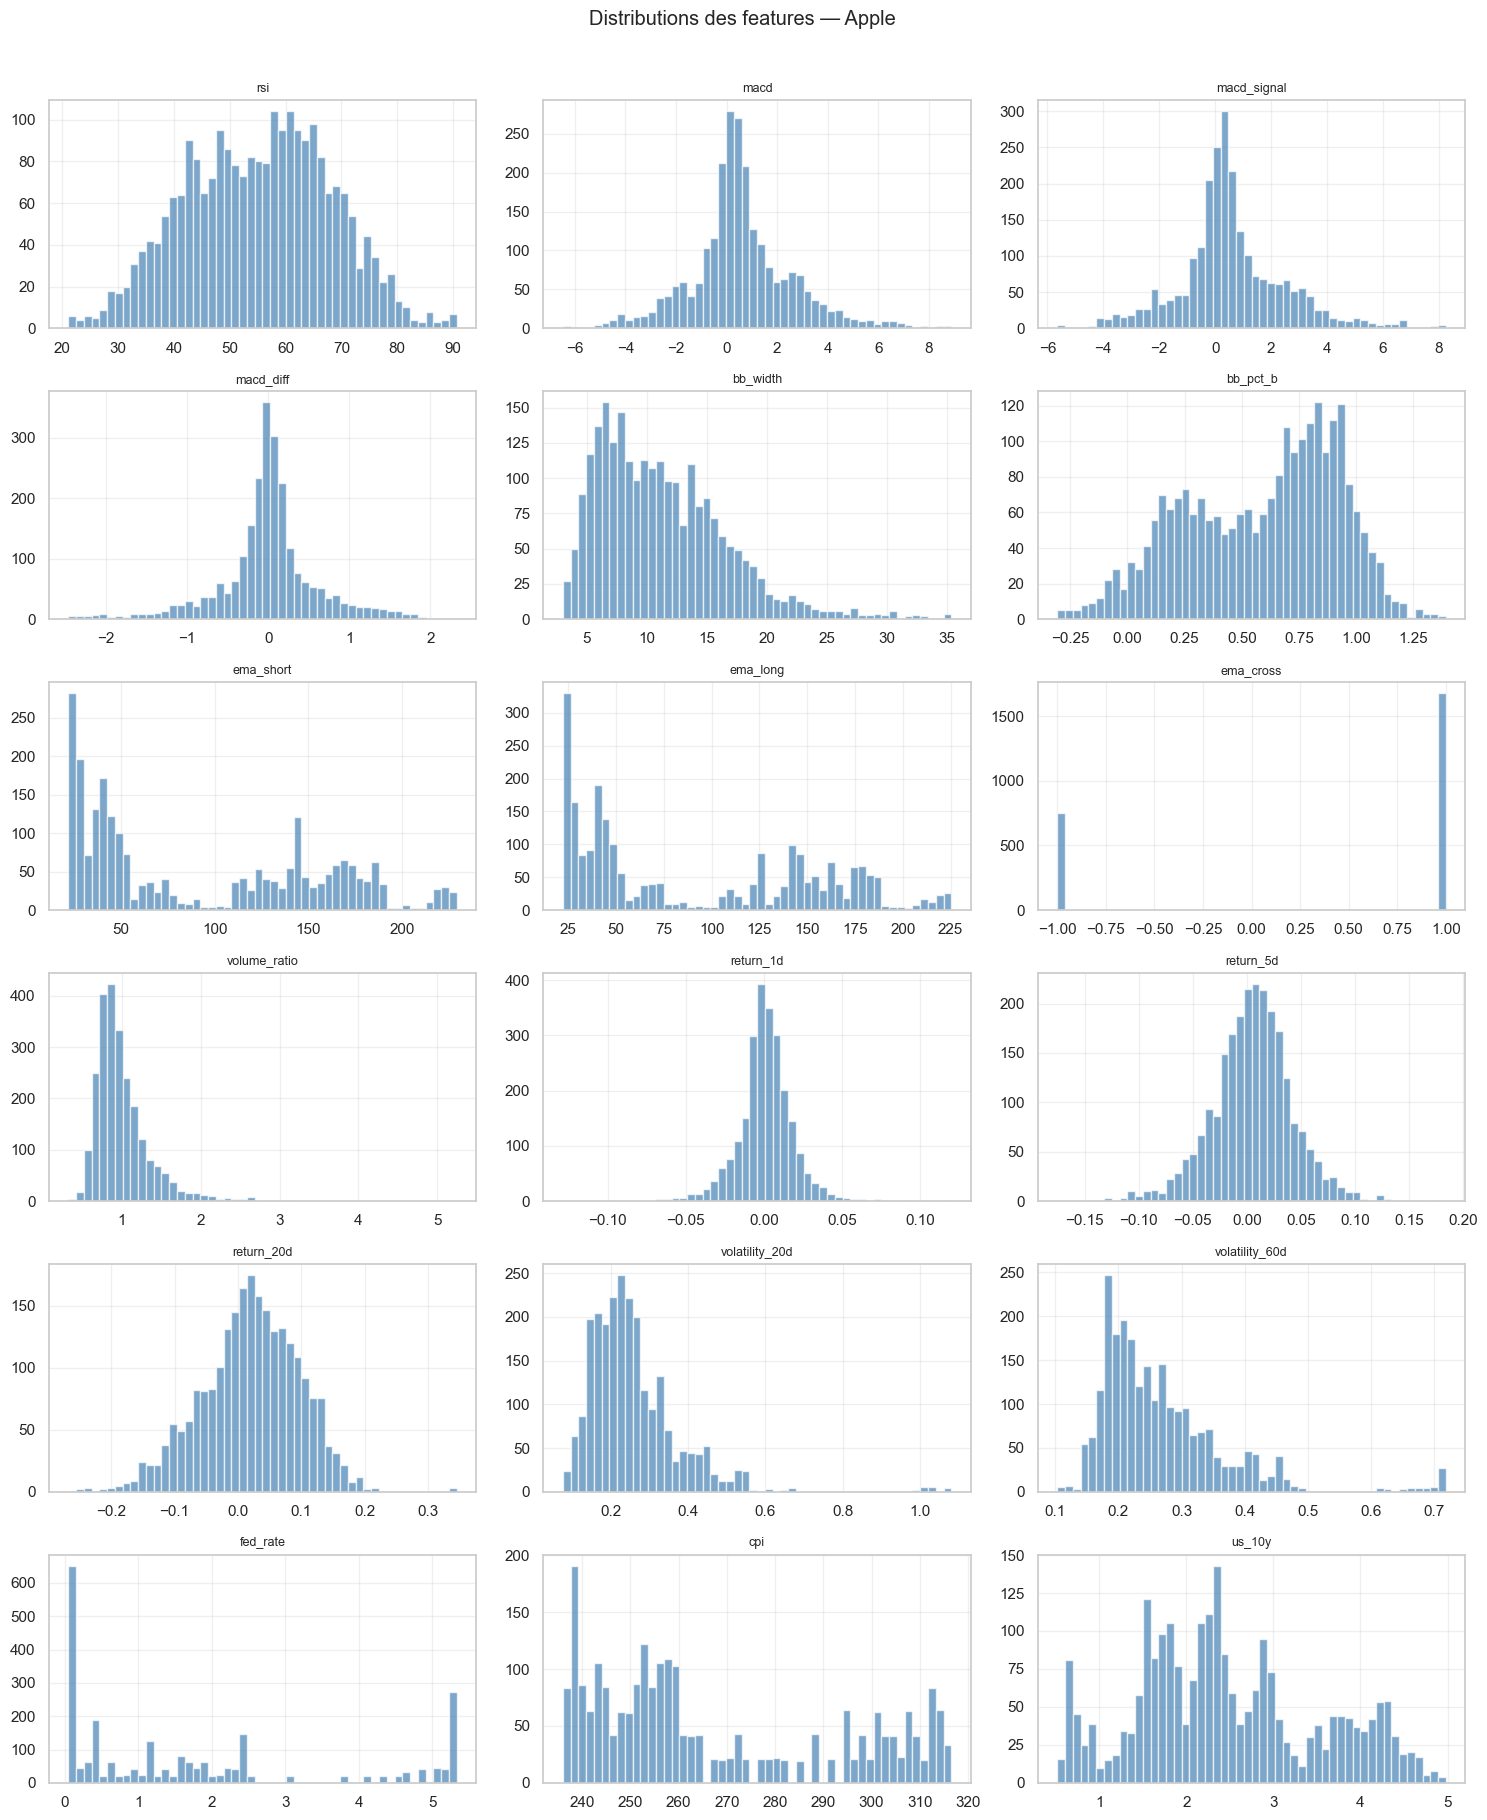

In [13]:
# Distributions des features — détecter les valeurs aberrantes
n_cols = 3
n_rows = (len(available) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(available):
    df_clean[feat].hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Distributions des features — {TICKER_LABELS[TICKER]}', y=1.01)
plt.tight_layout()
plt.show()

## 7. Sauvegarde dans data/processed/

In [14]:
# Sauvegarde pour tous les tickers
from pathlib import Path

processed_dir = DATA_PROCESSED_DIR / 'features'
processed_dir.mkdir(parents=True, exist_ok=True)

for ticker in ALL_TICKERS:
    prices = load_raw_prices(ticker)
    df_f   = build_feature_matrix(prices, macro_df=macro, add_targets=True)
    df_f   = df_f.dropna(subset=['target_trend', 'target_volatility'])

    path = processed_dir / f"{ticker.replace('=', '_')}_features.csv"
    df_f.to_csv(path)
    print(f'{ticker:8s} → {df_f.shape[0]} lignes sauvegardées : {path.name}')

print('\nFeature engineering terminé. Prochaine étape : 03_modeling.ipynb')

MC.PA    → 2470 lignes sauvegardées : MC.PA_features.csv
TTE.PA   → 2470 lignes sauvegardées : TTE.PA_features.csv
AAPL     → 2425 lignes sauvegardées : AAPL_features.csv
MSFT     → 2425 lignes sauvegardées : MSFT_features.csv
GC=F     → 2422 lignes sauvegardées : GC_F_features.csv
SI=F     → 2422 lignes sauvegardées : SI_F_features.csv
PL=F     → 2413 lignes sauvegardées : PL_F_features.csv

Feature engineering terminé. Prochaine étape : 03_modeling.ipynb
